# Student Performance Analysis
Run this after `01_Données_cleaning.py` has produced `../Données/clean/panel.csv`.



## Why Panel Format?

A **panel DonnéesEnsemble** Moyennes one row = one student, all their Données in Colonnes.

| id | promo | moy_s1 | moy_s2 | moy_ann | genre | bac | algo.num1 | prog java 2 | ... |
|---|---|---|---|---|---|---|---|---|---|
| 02d6... | 2 | 15.22 | 15.84 | 15.53 | m | math | 16.5 | 12.6 | ... |

Without this, your Données lives in 5 separate tables and every analysis
requires re-joining them. With panel.csv you just load one Fichier and go.
It also lets sklearn, seaborn, and any other library work directly —
they all expect (n_samples × n_Caractéristiques).



## 0. Ensembleup



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from pathlib import Path

panel = pd.read_csv("../data/clean/panel.csv")
sns.set_theme(style="whitegrid")

# subject-grade Colonnes (everything that isn't a Métadonnées column)
META = ["id", "promo", "moy_s1", "moy_s2", "moy_ann", "rang", "passage",
        "passage_bin", "rang_norm", "delta_s2_s1", "top_quartile",
        "bottom_quartile", "is_outlier", "genre", "origine", "bac",
        "licence", "promotion"]
subject_cols = [c for c in panel.columns if c not in META and not c.startswith("mod_")]

print(f"Students: {len(panel)}  |  Promos: {sorted(panel.promo.unique())}")
print(f"Subject columns: {subject_cols}")
panel.head(3)


Students: 100  |  Promos: [np.int64(1), np.int64(2), np.int64(3)]
Subject columns: ['Devp mob', 'TOEIC3', 'TOEIC4', 'agile', 'algo num2', 'algo.num1', 'appr auto', "ches de mkv-fil d'at", 'cloud comp', 'devops1', 'dt des entpses', 'ent de données', "fond de l'IA", 'gest des ress hum', 'init au big data', 'mod UML/OCL', 'opt prog lineaire', 'opt&prog nn lin', 'prog java 2', 'prog log', 'sem et proj', 'tech sem', 'test log', 'théo de l inf cod cr', 'virtualisation', 'vtes ind']


,id,promo,moy_s1,moy_s2,moy_ann,rang,passage,promotion,genre,origine,...,mod_Mathématiques 5,mod_Mathématiques 6,mod_Sémantique & Sys distribué,"mod_Th info, entrepot & IHM",delta_s2_s1,passage_bin,top_quartile,bottom_quartile,rang_norm,is_outlier
0,02d62872c6,2,15.22,15.84,15.53,2,Admis,2,m,sfax,...,17.6,16.58,15.06,14.62,0.62,1,1,0,0.971429,0
1,033574f04c,2,13.52,14.52,14.02,8,Admis,2,m,sfax,...,14.3,13.32,12.85,13.02,1.00,1,1,0,0.800000,0
2,033b92fdb6,3,11.97,12.56,12.27,22,Admis,3,m,sfax,...,12.6,14.12,9.92,10.42,0.59,1,0,0,0.322581,0


## 1. Performance by Promotion



/tmp/ipykernel_112806/2250935827.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=panel, x="promo", y="moy_ann", palette="Set2", ax=axes[0])


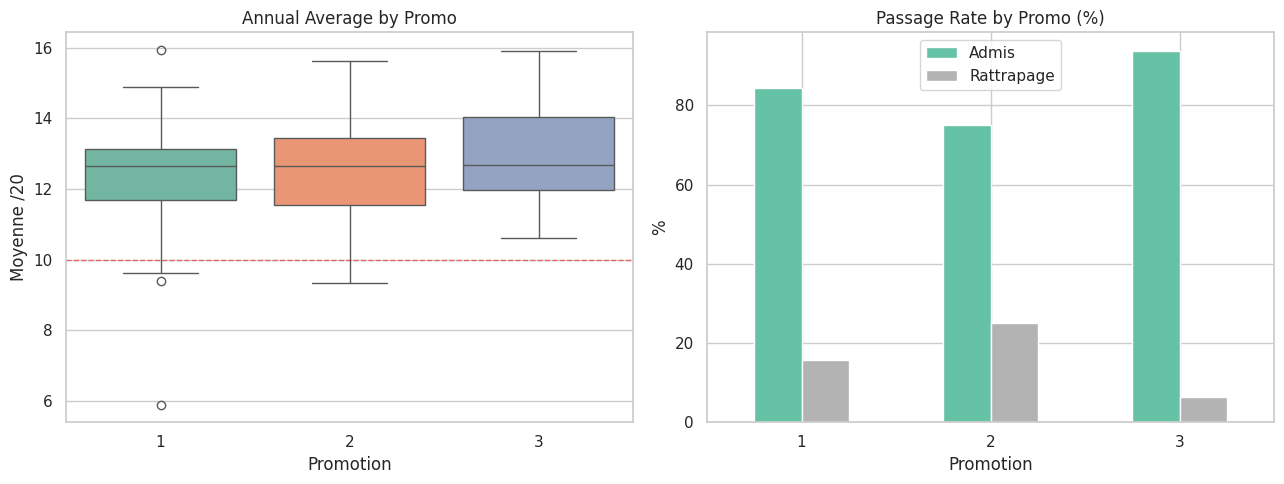

        mean   std    min    max
promo                           
1      12.27  1.82   5.90  15.93
2      12.56  1.54   9.34  15.62
3      12.91  1.31  10.62  15.89


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
sns.boxplot(data=panel, x="promo", y="moy_ann", palette="Set2", ax=axes[0])
axes[0].axhline(10, color="red", lw=1, linestyle="--", alpha=0.5)
axes[0].set(title="Annual Average by Promo", xlabel="Promotion", ylabel="Moyenne /20")

# Passage rate
passage_rate = (panel.groupby("promo")["passage"]
                .value_counts(normalize=True)
                .unstack()
                .fillna(0) * 100)
passage_rate.plot.bar(ax=axes[1], colormap="Set2", edgecolor="white", rot=0)
axes[1].set(title="Passage Rate by Promo (%)", xlabel="Promotion", ylabel="%")
axes[1].legend(title="")

plt.tight_layout()
plt.show()

# Résumé table
print(panel.groupby("promo")["moy_ann"]
      .agg(["mean", "std", "min", "max"])
      .round(2))


## 2. Semester Progression (S1 → S2)



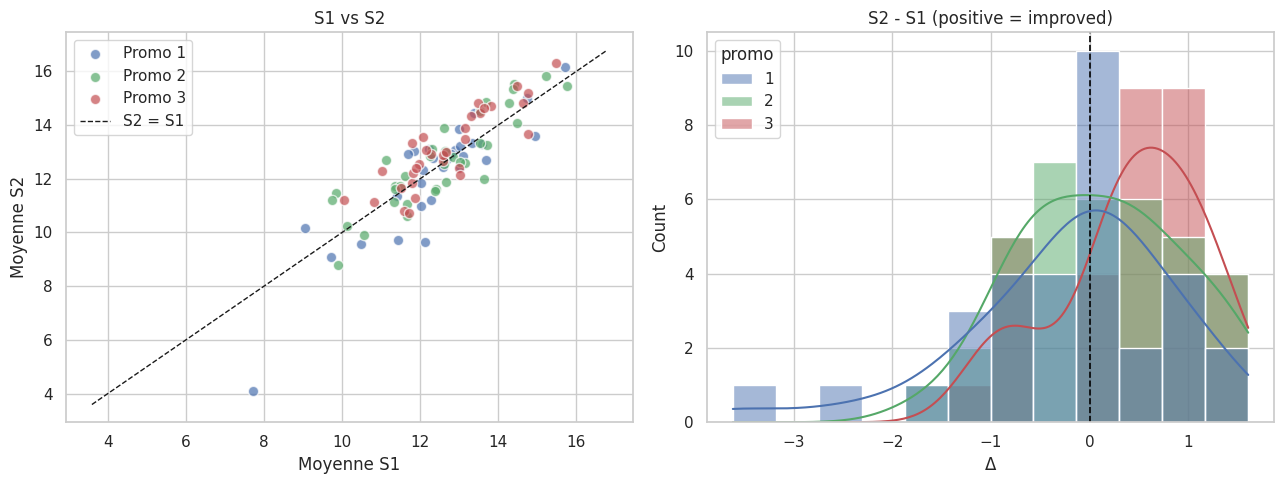


Mean S2-S1 improvement per promo:
promo
1   -0.211
2    0.134
3    0.422
Name: delta_s2_s1, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# S1 vs S2 Dispersion
colors = {1: "#4C72B0", 2: "#55A868", 3: "#C44E52"}
for p in [1, 2, 3]:
    sub = panel[panel.promo == p]
    axes[0].scatter(sub.moy_s1, sub.moy_s2, color=colors[p],
                    alpha=0.7, label=f"Promo {p}", edgecolors="white", s=55)
lim = [panel[["moy_s1","moy_s2"]].min().min()-0.5,
       panel[["moy_s1","moy_s2"]].max().max()+0.5]
axes[0].plot(lim, lim, "k--", lw=1, label="S2 = S1")
axes[0].set(title="S1 vs S2", xlabel="Moyenne S1", ylabel="Moyenne S2")
axes[0].legend()

# Delta Distribution
sns.histplot(data=panel, x="delta_s2_s1", hue="promo",
             palette=colors, kde=True, bins=12, ax=axes[1])
axes[1].axvline(0, color="black", lw=1.2, linestyle="--")
axes[1].set(title="S2 - S1 (positive = improved)", xlabel="Δ")

plt.tight_layout()
plt.show()

print("\nMean S2-S1 improvement per promo:")
print(panel.groupby("promo")["delta_s2_s1"].mean().round(3))


## 3. Subject-Level Carte thermique



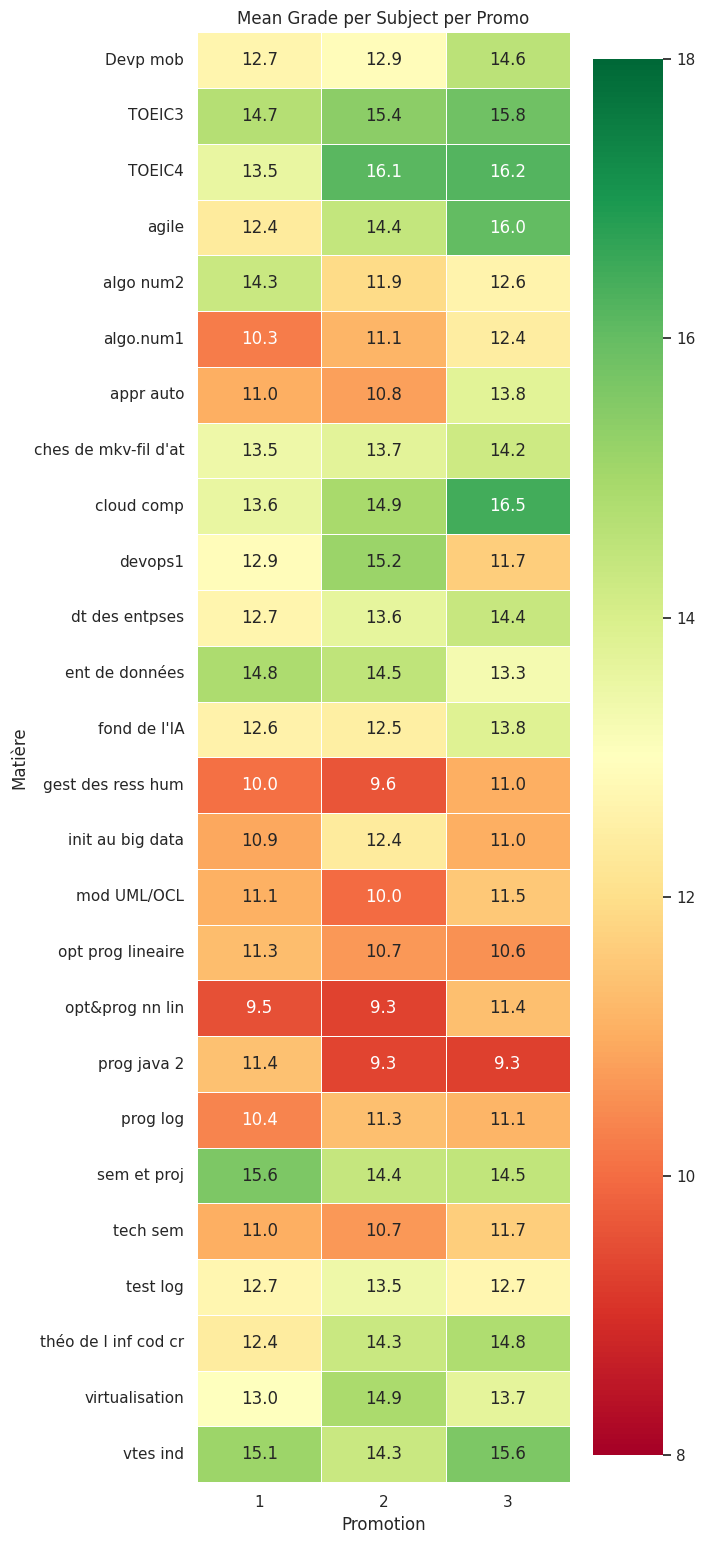

In [4]:
if subject_cols:
    heatmap_data = panel.groupby("promo")[subject_cols].mean().T
    fig, ax = plt.subplots(figsize=(7, max(3, len(subject_cols) * 0.6)))
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn",
                vmin=8, vmax=18, ax=ax, linewidths=0.5)
    ax.set(title="Mean Grade per Subject per Promo",
           xlabel="Promotion", ylabel="Matière")
    plt.tight_layout()
    plt.show()
else:
    print("No subject columns found — check that notes.csv was joined in cleaning.")


## 4. ACP — What Structure Exists in the Grades?

ACP finds the directions of Maximumimumimum Variance in the grade Matrice.
Each student becomes a point; nearby points have similar grade proFichiers.
The arlignes show which subjects pull in which direction.



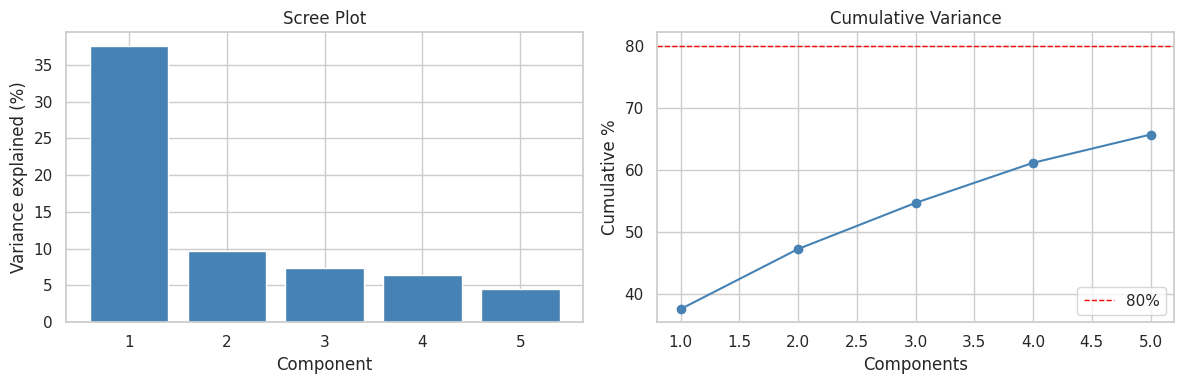

6 component(s) explain ≥ 80% of variance
PC1=37.6%   PC2=9.7%


In [5]:
features = subject_cols if subject_cols else ["moy_s1", "moy_s2"]
X = panel[features].fillna(panel[features].mean())
X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=min(len(features), 5))
X_pca = pca.fit_transform(X_std)

# Scree
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
var = pca.explained_variance_ratio_ * 100
axes[0].bar(range(1, len(var)+1), var, color="steelblue", edgecolor="white")
axes[0].set(title="Scree Plot", xlabel="Component", ylabel="Variance explained (%)")

axes[1].plot(range(1, len(var)+1), var.cumsum(), "o-", color="steelblue")
axes[1].axhline(80, color="red", lw=1, linestyle="--", label="80%")
axes[1].set(title="Cumulative Variance", xlabel="Components", ylabel="Cumulative %")
axes[1].legend()
plt.tight_layout()
plt.show()

n_needed = int(np.searchsorted(var.cumsum(), 80)) + 1
print(f"{n_needed} component(s) explain ≥ 80% of variance")
print(f"PC1={var[0]:.1f}%   PC2={var[1]:.1f}%")


### Biplot — étudiants and Subjects Together



/tmp/ipykernel_112806/4033657042.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


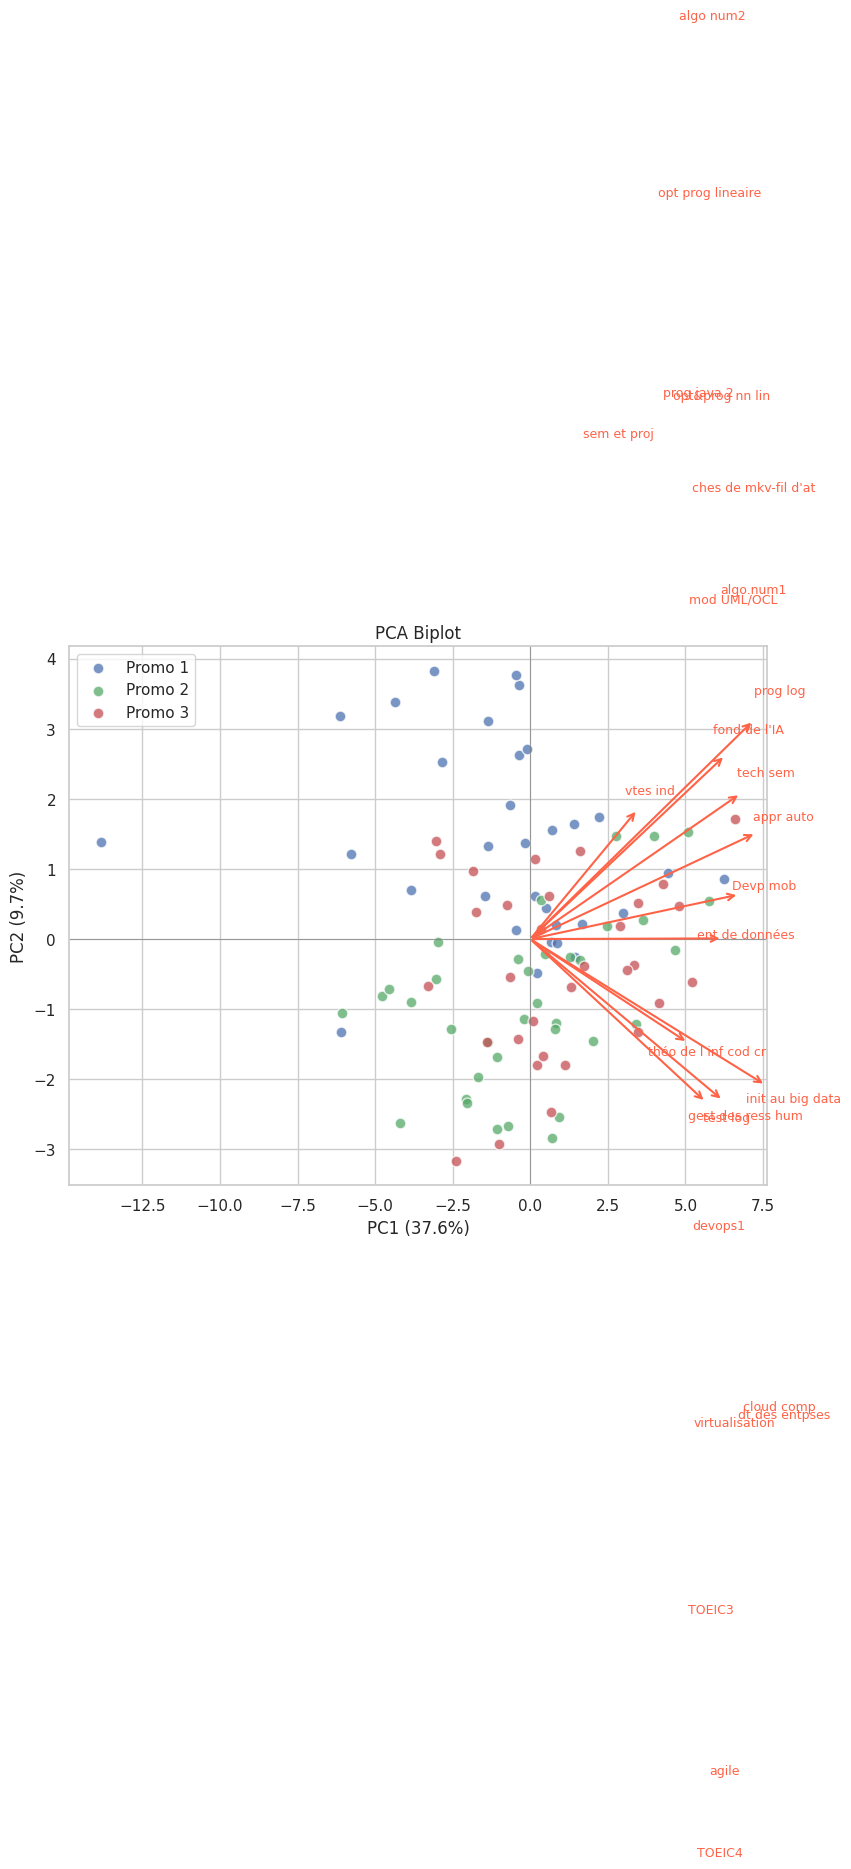

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

for p in [1, 2, 3]:
    mask = panel.promo.values == p
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=colors[p],
               alpha=0.75, s=60, edgecolors="white", label=f"Promo {p}")

# Loading arlignes
scale = 2.2 * np.abs(X_pca[:, :2]).max()
for j, feat in enumerate(features):
    u = pca.components_[0, j] * scale
    v = pca.components_[1, j] * scale
    ax.annotate("", xy=(u, v), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="tomato", lw=1.5))
    ax.text(u * 1.12, v * 1.12, feat, color="tomato", fontsize=9, ha="center")

ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set(title="PCA Biplot", xlabel=f"PC1 ({var[0]:.1f}%)", ylabel=f"PC2 ({var[1]:.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Clustering — Natural Student Groups



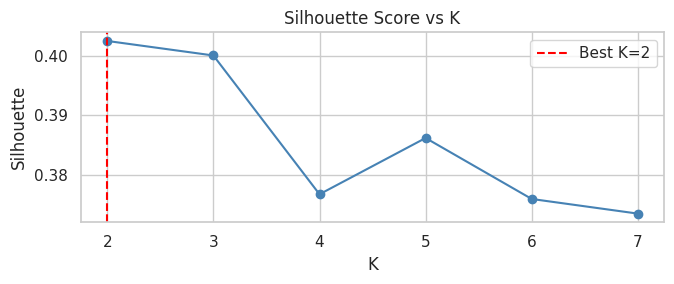

Best K = 2


In [7]:
# Choose K with Silhouette Scores
from sklearn.metrics import silhouette_score

K_range = range(2, min(8, len(panel)//5))
sil = [silhouette_score(X_pca[:, :2], KMeans(k, random_state=42, n_init=10).fit_predict(X_pca[:, :2]))
       for k in K_range]

best_k = list(K_range)[np.argmax(sil)]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(K_range), sil, "o-", color="steelblue")
ax.axvline(best_k, color="red", lw=1.5, linestyle="--", label=f"Best K={best_k}")
ax.set(title="Silhouette Score vs K", xlabel="K", ylabel="Silhouette")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best K = {best_k}")


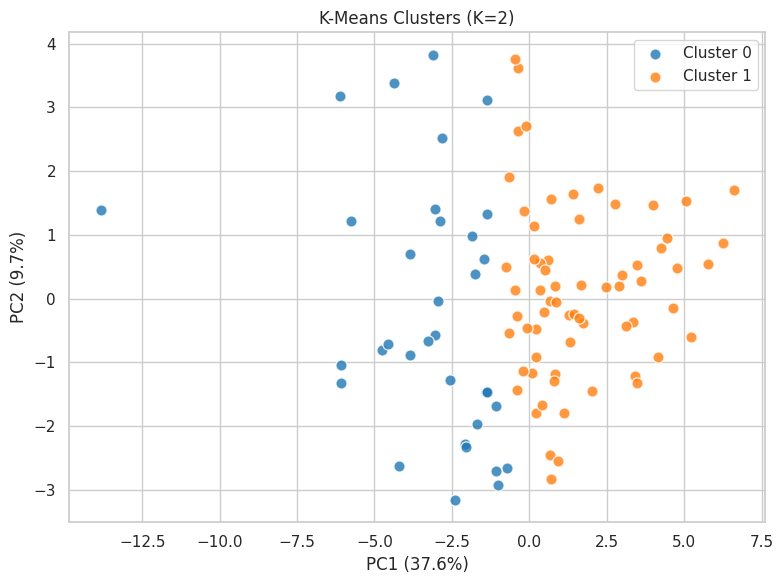


Cluster profiles (sorted by annual average):
         moy_ann  moy_s1  moy_s2  admis_rate
cluster                                     
1          13.41   13.26   13.57        0.97
0          10.96   11.09   10.83        0.59


In [8]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
panel["cluster"] = km.fit_predict(X_pca[:, :2])

# Dispersion coloured by cluster
fig, ax = plt.subplots(figsize=(8, 6))
cluster_pal = sns.color_palette("tab10", best_k)
for cl in range(best_k):
    mask = panel.cluster == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=cluster_pal[cl],
               alpha=0.8, s=65, edgecolors="white", label=f"Cluster {cl}")
ax.set(title=f"K-Means Clusters (K={best_k})",
       xlabel=f"PC1 ({var[0]:.1f}%)", ylabel=f"PC2 ({var[1]:.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()

# ProFichier each cluster
profile = panel.groupby("cluster")[["moy_ann", "moy_s1", "moy_s2",
                                     "passage_bin"]].mean().round(2)
profile.columns = ["moy_ann", "moy_s1", "moy_s2", "admis_rate"]
profile = profile.sort_values("moy_ann", ascending=False)
print("\nCluster profiles (sorted by annual average):")
print(profile)


## 6. Predict Passage Risque (Logistic Régression)

Can we fDécaDécalagee étudiants at Risque of rattrapage using their grades?



Logistic Regression — 5-fold AUC: 0.942 (+/- 0.045)
Baseline (always predict Admis):   0.840


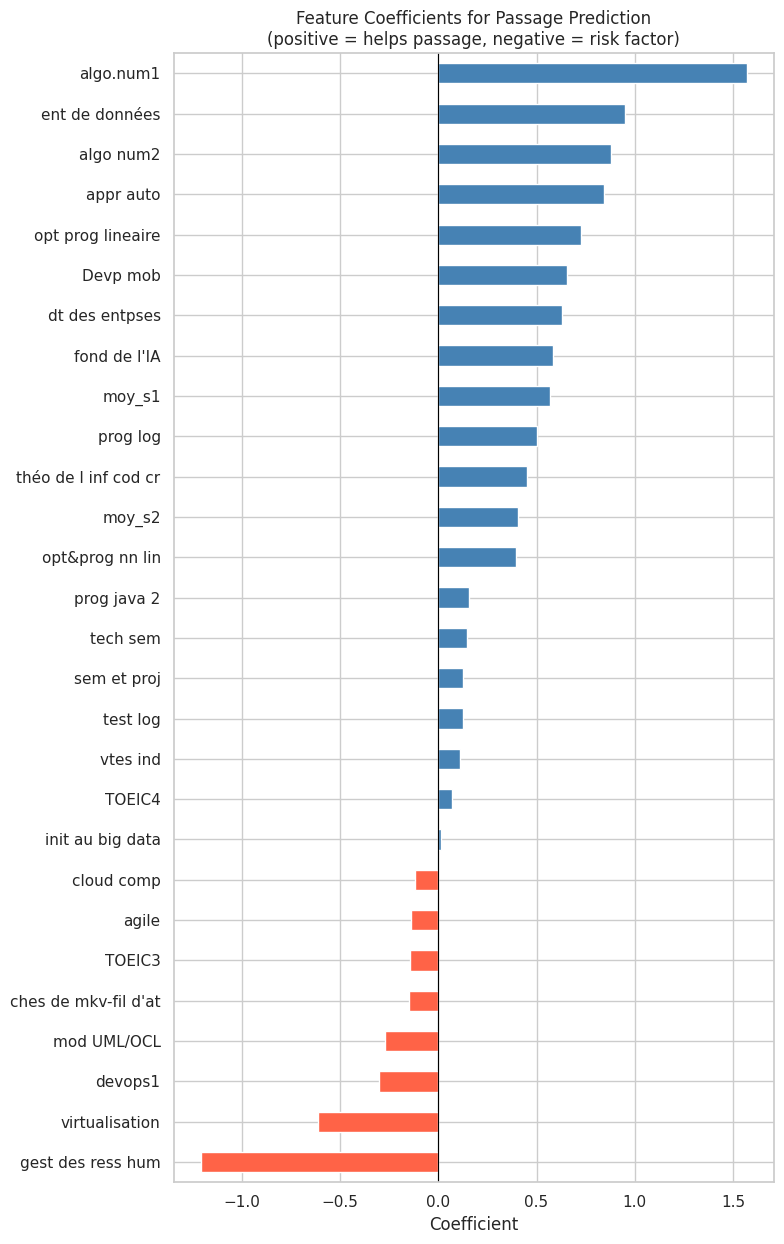

In [9]:
feat_pred = ["moy_s1", "moy_s2"] + subject_cols
feat_pred = [c for c in feat_pred if c in panel.columns]
X_pred = panel[feat_pred].fillna(panel[feat_pred].mean())
y      = panel["passage_bin"]

model = LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)
scores = cross_val_score(model, StandardScaler().fit_transform(X_pred), y,
                         cv=5, scoring="roc_auc")

print(f"Logistic Regression — 5-fold AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")
print(f"Baseline (always predict Admis):   {y.mean():.3f}")

# Fit once for coefficients
model.fit(StandardScaler().fit_transform(X_pred), y)
coef = pd.Series(model.coef_[0], index=feat_pred).sort_values()

fig, ax = plt.subplots(figsize=(8, max(3, len(coef) * 0.45)))
coef.plot.barh(ax=ax, color=["tomato" if v < 0 else "steelblue" for v in coef])
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Feature Coefficients for Passage Prediction\n"
             "(positive = helps passage, negative = risk factor)",
       xlabel="Coefficient")
plt.tight_layout()
plt.show()


## 7. Résumé

| Step | What we found |
|---|---|
| Promo comparison | See boxplot — are promos Tendanceing up or down? |
| S1→S2 progression | Positif delta = étudiants improved in S2 |
| Subject Carte thermique | Which subjects are hard across all promos? |
| ACP | How many independent "dimensions" exist in the grades? |
| Clusters | How many distinct student proFichiers are there? |
| Prédiction | Which subjects best predict passing? |
